# Binary Classification on Tabular Data - Predicting Heart Disease

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

devices = tf.config.list_physical_devices()
print(devices)
for device in devices:
    print(tf.config.experimental.get_device_details(device))
    print(f"Memory available: {tf.config.experimental.get_device_details(device).get('device_memory_size', 'N/A')}")

2026-01-13 18:41:23.362442: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-13 18:41:23.403080: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-13 18:41:24.384226: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
{}
Memory available: N/A
{'compute_capability': (8, 6), 'device_name': 'NVIDIA GeForce RTX 3060'}
Memory available: N/A


In [2]:
# Sources of randomness
# - starting values of weights
# - Processing order of minibatches in SGD
# - data split in train/test
# - dropout from regularization

keras.utils.set_random_seed(42)

## Data Collection and PreProcessing

In [3]:
df = pd.read_csv("http://storage.googleapis.com/download.tensorflow.org/data/heart.csv")

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


In [5]:
df.target.value_counts(normalize=True, dropna=False)

target
0    0.726073
1    0.273927
Name: proportion, dtype: float64

So baseline should be 72.60 % accuracy

In [6]:
# Preprocessing the data 

categorial_variables = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "ca",
    "thal",
]

numerics = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "slope"
]

In [7]:
df = pd.get_dummies(
    df, 
    columns=categorial_variables, 
    dtype=np.int32)

df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,63,145,233,150,2.3,3,0,0,1,0,...,0,1,0,0,0,0,0,1,0,0
1,67,160,286,108,1.5,2,1,0,1,0,...,1,0,0,0,1,0,0,0,1,0
2,67,120,229,129,2.6,2,0,0,1,0,...,1,0,0,1,0,0,0,0,0,1
3,37,130,250,187,3.5,3,0,0,1,0,...,0,1,0,0,0,0,0,0,1,0
4,41,130,204,172,1.4,1,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0


In [8]:
 # Splitting training and test sets. 
 # 80-20 
 
 # before standardization of data 
 
train_df =  df.sample(frac=0.8, random_state=42)
test_df = df.drop(train_df.index)

print(train_df.shape)
print(test_df.shape)
 

(242, 30)
(61, 30)


In [9]:
# Standardization
means = train_df[numerics].mean()
sd = train_df[numerics].std()

In [10]:
print(means)
type(means)

age          55.028926
trestbps    131.805785
chol        245.103306
thalach     147.475207
oldpeak       1.112397
slope         1.619835
dtype: float64


pandas.core.series.Series

In [11]:
train_df[numerics] = (train_df[numerics] - means) / sd
test_df[numerics] = (test_df[numerics] - means) / sd

In [12]:
train_df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
179,-0.668652,-0.789825,-1.803820,-0.940324,-0.258042,-0.997666,0,0,1,0,...,0,0,0,0,1,0,0,0,1,0
228,-0.003208,-0.217728,-0.752723,-0.765178,0.733167,0.611902,1,1,0,0,...,1,0,1,0,0,0,0,0,0,1
111,-0.114115,-1.247503,-0.583797,0.460844,0.402764,0.611902,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0
246,0.218607,-0.103308,-0.170865,1.161428,-0.918848,0.611902,0,1,0,0,...,0,0,1,0,0,0,0,0,1,0
60,1.216773,-0.675405,1.067928,0.154338,-0.588445,0.611902,0,0,1,0,...,0,1,0,0,0,0,0,0,1,0


In [13]:
# converting to numpy to feed to keras
train = train_df.to_numpy()
test = test_df.to_numpy()


In [14]:
# Delete target variable from train and test
train_X = np.delete(train, 6, axis=1)
test_X = np.delete(test, 6, axis=1)

In [15]:
train_X.shape, test_X.shape

((242, 29), (61, 29))

In [16]:
train_y = train[:, 6]
test_y = test[:, 6]
print(test_y.shape, train_y.shape )

(61,) (242,)


## Model Building

In [17]:
num_columns = train_X.shape[1]

input = keras.Input(shape=(num_columns,))
hidden = keras.layers.Dense(16, activation="relu", name="hidden")(input)
output = keras.layers.Dense(1, activation="sigmoid", name="output")(hidden)

model = keras.Model(input, output)
model.summary()

I0000 00:00:1768309885.731519  406967 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10247 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 497 (1.94 KB)

 Trainable params: 497 (1.94 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
(29 * 16) + 16 + (16*1) + 1

497

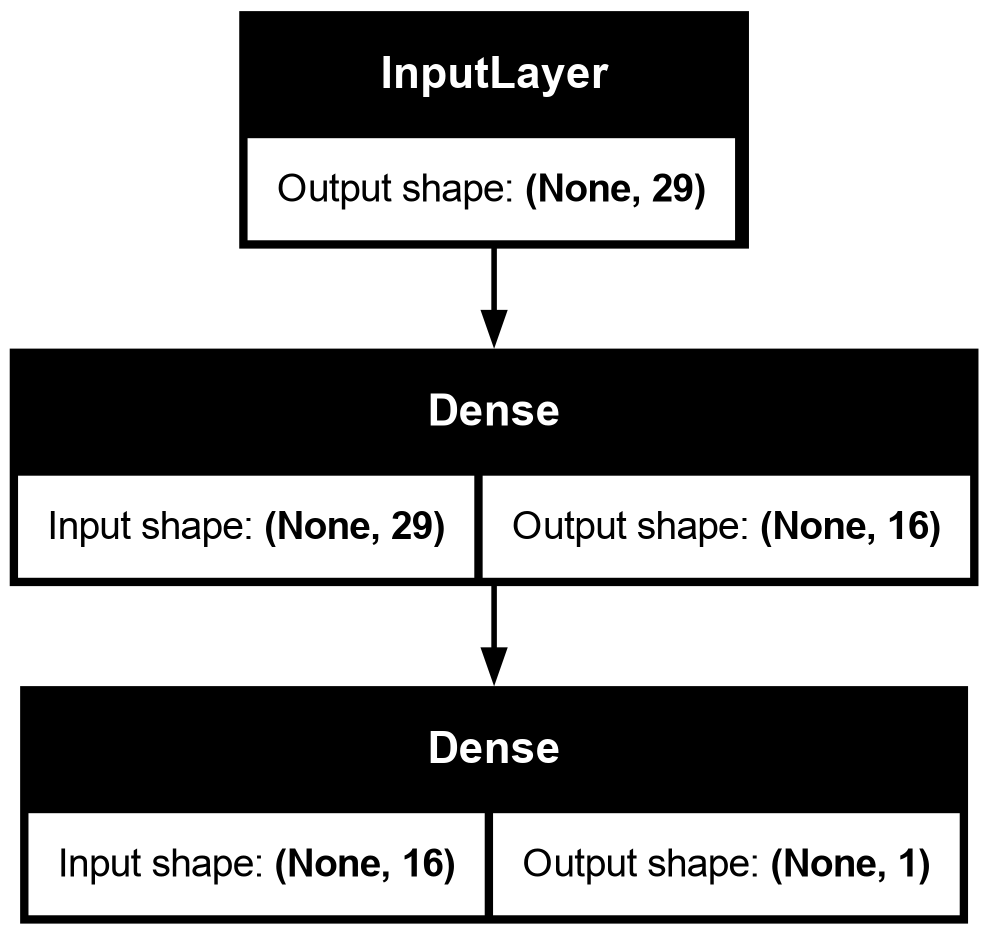

In [19]:
keras.utils.plot_model(model, show_shapes=True)

In [20]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"] # it's not actually being used in model, jsut being reportedto user
)


In [21]:
history = model.fit(
    train_X,
    train_y,
    epochs = 300,
    batch_size = 256,
    verbose = 1,
    validation_split = 0.2,
)

Epoch 1/300


2026-01-13 18:41:26.925134: I external/local_xla/xla/service/service.cc:163] XLA service 0x785ef0007eb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-13 18:41:26.925148: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-01-13 18:41:26.941362: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-13 18:41:27.043996: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5648 - loss: 0.7042

I0000 00:00:1768309887.719554  407151 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5648 - loss: 0.7042 - val_accuracy: 0.4898 - val_loss: 0.7231
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5699 - loss: 0.6975 - val_accuracy: 0.4898 - val_loss: 0.7192
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.5855 - loss: 0.6908 - val_accuracy: 0.5102 - val_loss: 0.7154
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6062 - loss: 0.6843 - val_accuracy: 0.5306 - val_loss: 0.7117
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6218 - loss: 0.6778 - val_accuracy: 0.5510 - val_loss: 0.7082
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6373 - loss: 0.6715 - val_accuracy: 0.5306 - val_loss: 0.7047
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6373 - loss: 0.6653 - val_accuracy: 0.5306 - val_loss: 0.7011
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.6373 - loss: 0.6591 - val_accuracy: 0.5306 - val_loss: 0.6977
Epoch 

In [22]:
history_dict = history.history
history_dict.keys()
 

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

## Results and analysis

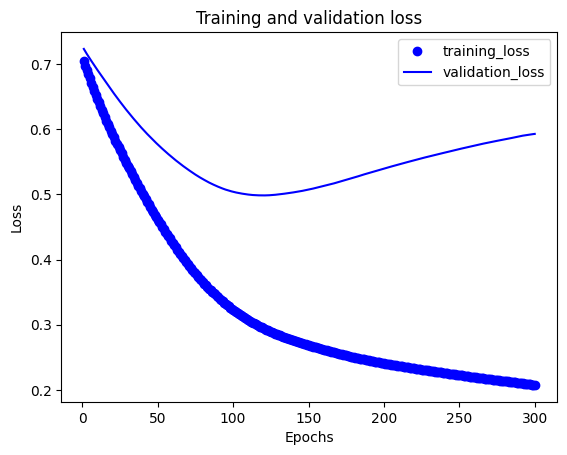

In [23]:
loss_values = history_dict["loss"]
validation_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "bo", label="training_loss")
plt.plot(epochs, validation_loss_values, "b", label="validation_loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

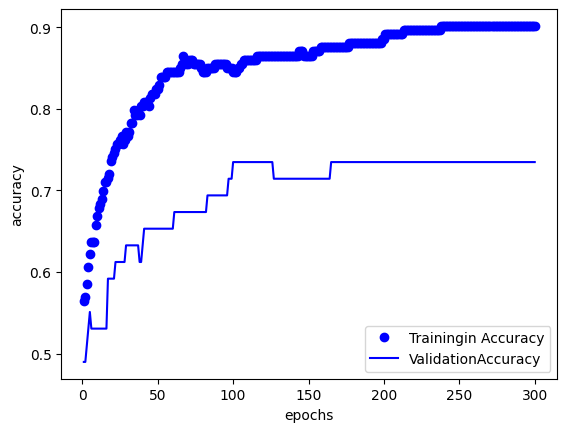

In [24]:
plt.clf()
accuracy = history_dict["accuracy"]
validation_accuracy = history_dict["val_accuracy"]
plt.plot(epochs, accuracy, "bo", label="Trainingin Accuracy")
plt.plot(epochs, validation_accuracy, "b", label="ValidationAccuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.show()

In [25]:
model.evaluate(
    test_X,
    test_y
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.8197 - loss: 0.3453


[0.3453156650066376, 0.8196721076965332]